# Speed Dating MLP Experiments: Optimizers and Architectures



## What is evaluated

- Main metric: **PR-AUC**.
- Secondary metrics: `F1-macro`, `balanced_accuracy`.


In [1]:
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)


In [2]:
from pathlib import Path

# Load train/test directly from data/processed.
processed_dir = Path('../data/processed')
x_train_path = processed_dir / 'X_train.csv'
y_train_path = processed_dir / 'y_train.csv'
x_test_path = processed_dir / 'X_test.csv'
y_test_path = processed_dir / 'y_test.csv'

missing = [
    pth.resolve() for pth in [x_train_path, y_train_path, x_test_path, y_test_path]
    if not pth.exists()
]
if missing:
    raise FileNotFoundError(f'Missing files: {missing}')

X_train_local = pd.read_csv(x_train_path)
Y_train_local = pd.read_csv(y_train_path).squeeze('columns')
X_test_local = pd.read_csv(x_test_path)
y_test_local = pd.read_csv(y_test_path).squeeze('columns')
print('Loaded train/test from data/processed')

if not isinstance(X_train_local, pd.DataFrame):
    X_train_local = pd.DataFrame(X_train_local)
if not isinstance(Y_train_local, pd.Series):
    Y_train_local = pd.Series(Y_train_local, name='target')
if not isinstance(X_test_local, pd.DataFrame):
    X_test_local = pd.DataFrame(X_test_local)
if not isinstance(y_test_local, pd.Series):
    y_test_local = pd.Series(y_test_local, name='target')

if len(X_train_local) != len(Y_train_local):
    raise ValueError(f'Length mismatch: len(X_train)={len(X_train_local)}, len(Y_train)={len(Y_train_local)}')
if len(X_test_local) != len(y_test_local):
    raise ValueError(f'Length mismatch: len(X_test)={len(X_test_local)}, len(y_test)={len(y_test_local)}')

print('X_train shape:', X_train_local.shape)
print('Y_train shape:', Y_train_local.shape)
print('X_test shape :', X_test_local.shape)
print('y_test shape :', y_test_local.shape)
print('Train class distribution:')
display(Y_train_local.value_counts(dropna=False).rename('count').to_frame())


Loaded train/test from data/processed
X_train shape: (6702, 51)
Y_train shape: (6702,)
X_test shape : (1676, 51)
y_test shape : (1676,)
Train class distribution:


,count
match,
0,5598
1,1104


In [3]:
RANDOM_STATE = 42
MAX_ITER = 500


In [4]:
def make_preprocessor():
    try:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', ohe),
    ])

    return ColumnTransformer([
        ('num', numeric_pipe, make_column_selector(dtype_include='number')),
        ('cat', categorical_pipe, make_column_selector(dtype_exclude='number')),
    ])


class TorchMLP(nn.Module):
    # use_bn=True adds BatchNorm1d after each Linear layer for stabler training.
    def __init__(self, input_dim, hidden=(128, 64), use_bn=True):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


label_values = sorted(pd.Series(Y_train_local).unique().tolist())
if len(label_values) != 2:
    raise ValueError(f'Expected binary target, got: {label_values}')
label_to_int = {label_values[0]: 0, label_values[1]: 1}


def encode_target(y_ser):
    return pd.Series(y_ser).map(label_to_int).to_numpy(dtype=np.float32)


# Finds the best probability threshold for converting predictions to classes.
# Chooses the threshold that maximizes F1 score (balances precision and recall),
# which is useful when the default 0.5 threshold is not optimal.
def tune_threshold_f1(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    if len(thr) == 0:
        return 0.5
    f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[np.argmax(f1)])


def build_optimizer(name, params, lr, momentum=0.9, nesterov=False):
    name = name.lower()
    if name == 'adam':
        return torch.optim.Adam(params, lr=lr, betas=(0.9, 0.999), eps=1e-8)
    if name == 'sgd':
        return torch.optim.SGD(
            params,
            lr=lr,
            momentum=momentum,
            nesterov=nesterov,
        )
    if name == 'rmsprop':
        return torch.optim.RMSprop(params, lr=lr, alpha=0.99, eps=1e-8)
    if name == 'adagrad':
        return torch.optim.Adagrad(params, lr=lr)
    if name == 'adadelta':
        return torch.optim.Adadelta(params, lr=lr, rho=0.9, eps=1e-6)
    raise ValueError(f'Unknown optimizer: {name}')


def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    out = {
        'pr_auc': float(average_precision_score(y_true, y_prob)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
    }
    return out


def balance_train_data(X_df, y_ser, method, random_state=42):
    if method == 'none':
        return X_df.copy(), y_ser.copy()

    train_df = X_df.copy()
    train_df['__target__'] = y_ser.values
    counts = train_df['__target__'].value_counts()
    classes = counts.index.tolist()

    parts = []
    if method == 'random_oversample':
        target_n = int(counts.max())
        for cls in classes:
            cls_df = train_df[train_df['__target__'] == cls]
            parts.append(cls_df.sample(n=target_n, replace=True, random_state=random_state))
    elif method == 'random_undersample':
        target_n = int(counts.min())
        for cls in classes:
            cls_df = train_df[train_df['__target__'] == cls]
            parts.append(cls_df.sample(n=target_n, replace=False, random_state=random_state))
    else:
        raise ValueError(f'Unknown balancing method: {method}')

    out = pd.concat(parts, axis=0).sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return out.drop(columns='__target__'), out['__target__']


def evaluate_torch_mlp(
    run_name,
    X_train_fit=None,
    y_train_fit=None,
    hidden=(128, 64),
    optimizer_name='adam',
    lr=1e-3,
    momentum=0.9,
    nesterov=False,
    epochs=100,
    batch_size=128,
    val_size=0.2,
    patience=3,
    class_balanced=True,
    k_select=None,
):
    X_fit = X_train_local if X_train_fit is None else X_train_fit
    y_fit = Y_train_local if y_train_fit is None else y_train_fit

    X_tr_raw, X_val_raw, y_tr_raw, y_val_raw = train_test_split(
        X_fit,
        y_fit,
        test_size=val_size,
        random_state=RANDOM_STATE,
        stratify=y_fit,
    )

    prep = make_preprocessor()
    X_tr = prep.fit_transform(X_tr_raw)
    X_val = prep.transform(X_val_raw)
    X_test = prep.transform(X_test_local)

    y_tr = encode_target(y_tr_raw)
    y_val = encode_target(y_val_raw)
    y_test = encode_target(y_test_local)

    selector = None
    effective_k = None

    # For mutual_info_classif we convert to dense first: sparse input is treated as discrete
    # by sklearn and can trigger clustering-metric warnings for continuous features.
    if hasattr(X_tr, 'toarray'):
        X_tr = X_tr.toarray()
        X_val = X_val.toarray()
        X_test = X_test.toarray()

    if k_select is not None:
        max_k = max(1, X_tr.shape[1] - 1)
        effective_k = min(int(k_select), max_k)
        mi_score = lambda X, y: mutual_info_classif(X, y, discrete_features=False, random_state=RANDOM_STATE)
        selector = SelectKBest(score_func=mi_score, k=effective_k)
        X_tr = selector.fit_transform(X_tr, y_tr)
        X_val = selector.transform(X_val)
        X_test = selector.transform(X_test)

    X_tr = np.asarray(X_tr, dtype=np.float32)
    X_val = np.asarray(X_val, dtype=np.float32)
    X_test = np.asarray(X_test, dtype=np.float32)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    # BatchNorm is enabled by default; set use_bn=False in TorchMLP call if needed.
    model = TorchMLP(input_dim=X_tr.shape[1], hidden=hidden, use_bn=True).to(device)

    pos_weight = None
    # For imbalanced data: increase positive-class loss weight.
    if class_balanced:
        pos = float((y_tr == 1).sum())
        neg = float((y_tr == 0).sum())
        pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = build_optimizer(
        optimizer_name,
        model.parameters(),
        lr=lr,
        momentum=momentum,
        nesterov=nesterov,
    )

    x_val_t = torch.from_numpy(X_val).to(device)
    y_val_t = torch.from_numpy(y_val).to(device)
    x_test_t = torch.from_numpy(X_test).to(device)
    y_test_t = torch.from_numpy(y_test).to(device)

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=batch_size,
        shuffle=True,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_pr_auc = -np.inf
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            val_logits = model(x_val_t)
            test_logits = model(x_test_t)
            val_prob = torch.sigmoid(val_logits).detach().cpu().numpy()
            val_pr_auc = float(average_precision_score(y_val, val_prob))
            val_loss = float(criterion(val_logits, y_val_t).detach().cpu())
            test_loss = float(criterion(test_logits, y_test_t).detach().cpu())

        history.append({
            'epoch': epoch,
            'train_loss': float(np.mean(epoch_losses)) if epoch_losses else np.nan,
            'val_loss': val_loss,
            'test_loss': test_loss,
            'val_pr_auc': val_pr_auc,
        })

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_prob_best = torch.sigmoid(model(x_val_t)).detach().cpu().numpy()
        test_prob = torch.sigmoid(model(x_test_t)).detach().cpu().numpy()

    # Validation-tuned threshold is then applied to test probabilities.
    threshold = tune_threshold_f1(y_val, val_prob_best)
    row = compute_metrics(y_test, test_prob, threshold)
    row['run'] = run_name
    row['train_size'] = len(X_fit)
    row['best_epoch'] = int(best_epoch)
    row['threshold'] = float(threshold)
    row['optimizer'] = optimizer_name
    row['hidden_layer_sizes'] = str(tuple(hidden))
    if effective_k is not None:
        row['k_selected'] = int(effective_k)

    fitted = {
        'model': model,
        'preprocessor': prep,
        'selector': selector,
        'threshold': threshold,
        'label_to_int': label_to_int,
        'device': str(device),
        'history': history,
    }
    return row, fitted


### Early Stopping Criterion

In this assignment, `patience` is applied to **validation PR-AUC** improvement, not to training loss or validation loss.
This choice is intentional because the primary objective is imbalanced-class ranking quality, and PR-AUC is the target selection metric.


### Activation Functions Used

- Hidden layers use **ReLU** activation (`nn.ReLU()`).
- The output layer is **linear** (`nn.Linear(..., 1)`) and does not apply sigmoid inside the model.
- Probabilities are computed later with `torch.sigmoid(logits)`, interpreted as the probability of the positive class (`P(y=1|x)`).
- Training uses `BCEWithLogitsLoss`, which applies sigmoid internally in a numerically stable way.


## 1) Optimizer comparison

- Evaluate optimizer families commonly used in adaptive and momentum-based training (`Adam`, `SGD+Nesterov`, `RMSProp`, `AdaGrad`, `AdaDelta`)
- Use a fixed tabular architecture: `(256, 128, 64)`
- Apply imbalance-aware training via `pos_weight` and tune decision threshold using the precision-recall curve
- Maintain a controlled experimental setup across optimizer variants


In [5]:
optimizer_configs = [
    ('adam', dict(optimizer_name='adam', lr=1e-3)),
    ('sgd_nesterov', dict(optimizer_name='sgd', lr=3e-3, momentum=0.9, nesterov=True)),
    ('rmsprop', dict(optimizer_name='rmsprop', lr=1e-3)),
    ('adagrad', dict(optimizer_name='adagrad', lr=5e-3)),
    ('adadelta', dict(optimizer_name='adadelta', lr=1.0)),
]

optimizer_rows = []
optimizer_models = {}

for run_name, opt_params in optimizer_configs:
    row, fitted = evaluate_torch_mlp(
        run_name=run_name,
        hidden=(256, 128, 64),
        batch_size=256,
        class_balanced=True,
        epochs=100,
        patience=3,
        **opt_params,
    )
    optimizer_rows.append(row)
    optimizer_models[run_name] = fitted

optimizer_df = pd.DataFrame(optimizer_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
optimizer_df['rank_pr_auc'] = optimizer_df['pr_auc'].rank(ascending=False, method='min').astype(int)

display(
    optimizer_df[['run', 'pr_auc', 'f1_macro', 'balanced_accuracy', 'rank_pr_auc']]
)


,run,pr_auc,f1_macro,balanced_accuracy,rank_pr_auc
0,sgd_nesterov,0.295640,0.584612,0.631661,1
1,adam,0.268766,0.565848,0.622531,2
2,adagrad,0.265747,0.574843,0.613494,3
3,adadelta,0.258025,0.555532,0.614317,4
4,rmsprop,0.255729,0.534204,0.603784,5


**Decision — Optimizer: `sgd_nesterov`.**

`sgd_nesterov` is selected because it is rank 1 on PR-AUC (`0.295640`) and also has the strongest secondary metrics in this optimizer comparison (`f1_macro=0.584612`, `balanced_accuracy=0.631661`).


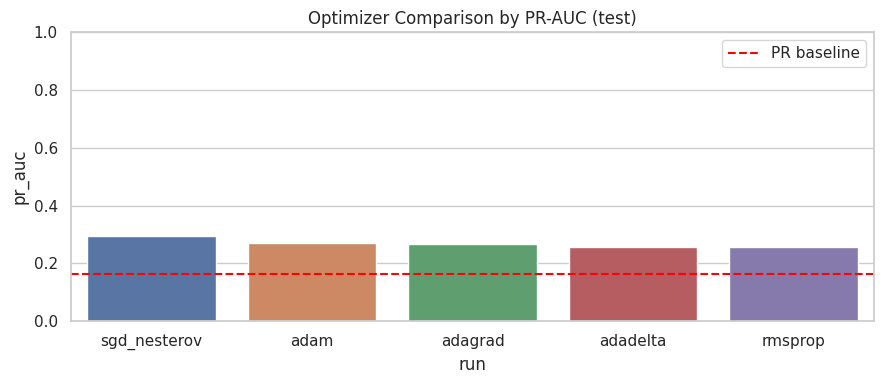

In [6]:
plt.figure()
plot_df = optimizer_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

pr_auc_baseline = float((pd.Series(y_test_local).map(label_to_int) == 1).mean())
plt.axhline(pr_auc_baseline, color='red', linestyle='--', linewidth=1.5, label='PR baseline')
plt.legend()

plt.title('Optimizer Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


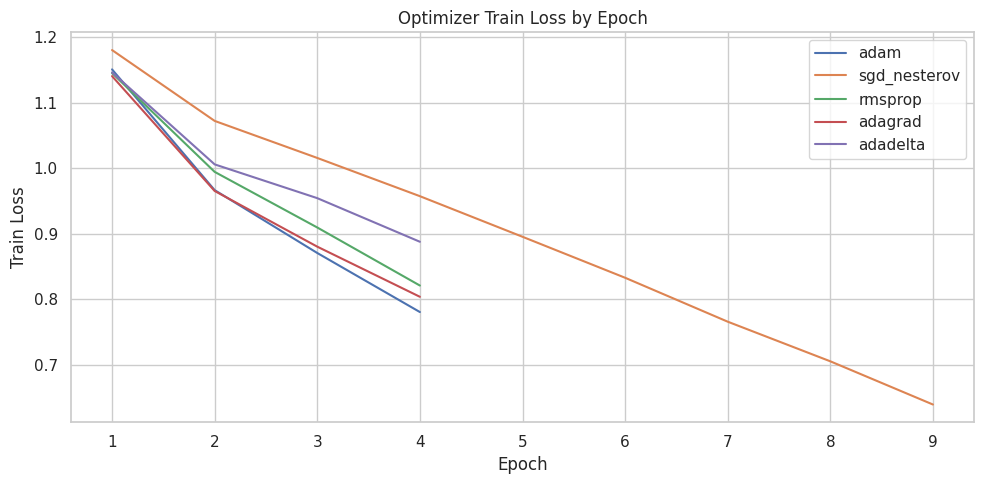

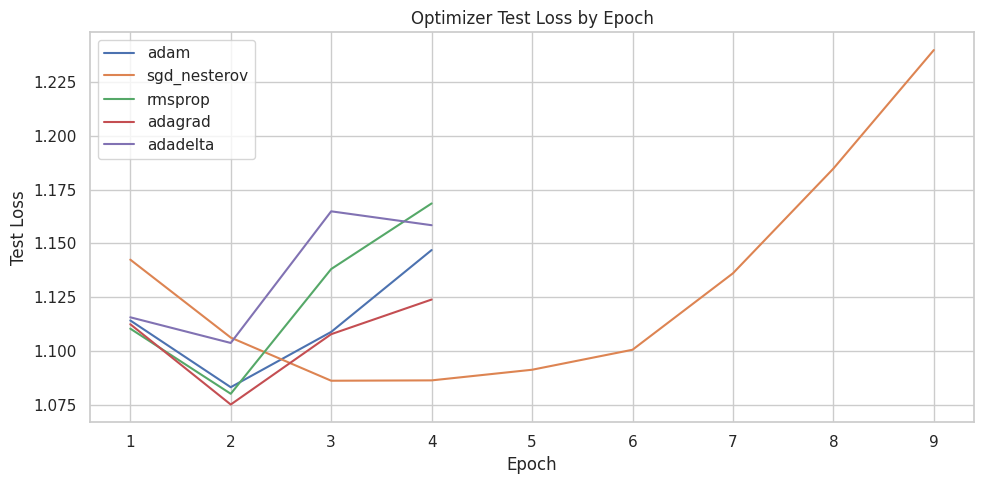

In [7]:
# Train loss only
plt.figure(figsize=(10, 5))
for run_name, fitted_obj in optimizer_models.items():
    history = fitted_obj.get('history', []) if isinstance(fitted_obj, dict) else []
    if history:
        epochs = [h['epoch'] for h in history]
        train_losses = [h.get('train_loss', np.nan) for h in history]
        plt.plot(epochs, train_losses, label=run_name)

plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Optimizer Train Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Test loss only
plt.figure(figsize=(10, 5))
for run_name, fitted_obj in optimizer_models.items():
    history = fitted_obj.get('history', []) if isinstance(fitted_obj, dict) else []
    if history:
        epochs = [h['epoch'] for h in history]
        test_losses = [h.get('test_loss', np.nan) for h in history]
        plt.plot(epochs, test_losses, label=run_name)

plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Optimizer Test Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()


## 2) Architecture comparison



In [8]:
architecture_configs = [
    ('narrow_128_64', (128, 64)),
    ('balanced_256_128_64', (256, 128, 64)),
    ('wide_512_256', (512, 256)),
    ('deep_512_256_128', (512, 256, 128)),
]

arch_rows = []
arch_models = {}

for run_name, layers in architecture_configs:
    row, fitted = evaluate_torch_mlp(
        run_name=run_name,
        hidden=layers,
        optimizer_name='adam',
        lr=1e-3,
        batch_size=256,
        class_balanced=True,
        epochs=100,
        patience=3,
    )
    row['hidden_layer_sizes'] = str(layers)
    arch_rows.append(row)
    arch_models[run_name] = fitted

arch_df = pd.DataFrame(arch_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
arch_df['rank_pr_auc'] = arch_df['pr_auc'].rank(ascending=False, method='min').astype(int)

display(
    arch_df[['run', 'hidden_layer_sizes', 'pr_auc', 'f1_macro', 'balanced_accuracy', 'rank_pr_auc']]
)


,run,hidden_layer_sizes,pr_auc,f1_macro,balanced_accuracy,rank_pr_auc
0,narrow_128_64,"(128, 64)",0.312388,0.507940,0.630663,1
1,wide_512_256,"(512, 256)",0.288100,0.517702,0.599374,2
2,deep_512_256_128,"(512, 256, 128)",0.273861,0.563569,0.604565,3
3,balanced_256_128_64,"(256, 128, 64)",0.268766,0.565848,0.622531,4


**Decision — Architecture: `narrow_128_64`.**

`narrow_128_64` is selected because it is rank 1 on PR-AUC (`0.312388`) in this architecture comparison; wider/deeper alternatives did not improve the primary objective.


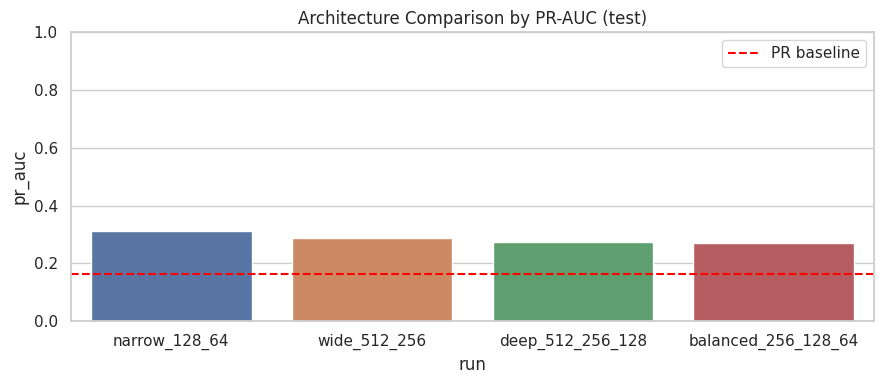

In [9]:
plt.figure()
plot_df = arch_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

pr_auc_baseline = float((pd.Series(y_test_local).map(label_to_int) == 1).mean())
plt.axhline(pr_auc_baseline, color='red', linestyle='--', linewidth=1.5, label='PR baseline')
plt.legend()

plt.title('Architecture Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


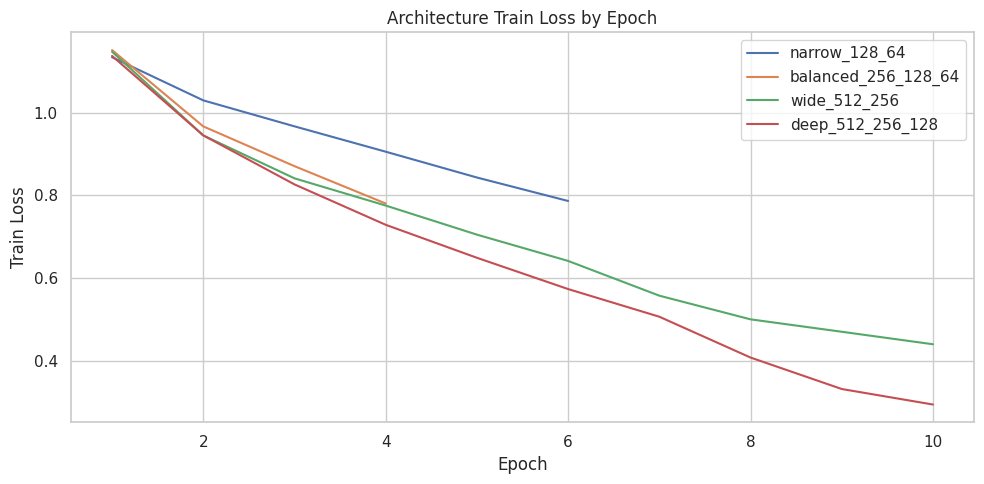

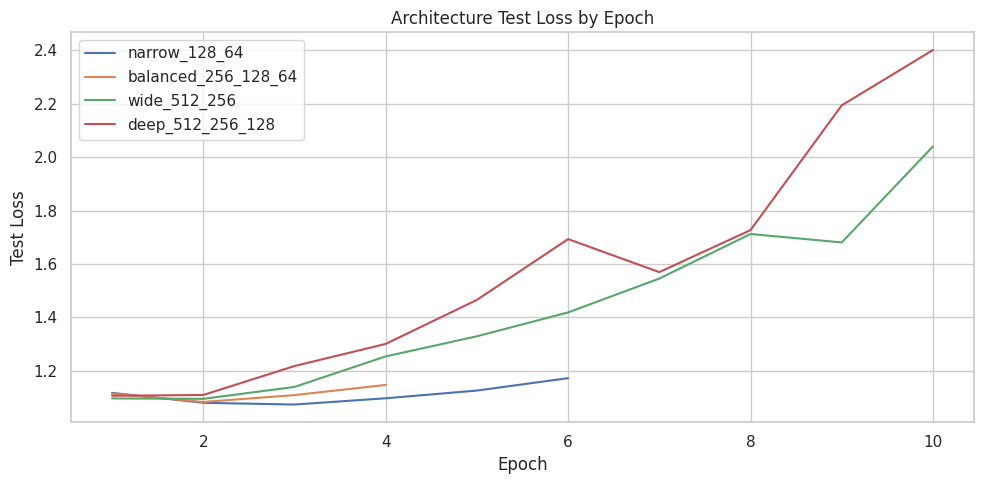

In [10]:
# Train loss only
plt.figure(figsize=(10, 5))
for run_name, fitted_obj in arch_models.items():
    history = fitted_obj.get('history', []) if isinstance(fitted_obj, dict) else []
    if history:
        epochs = [h['epoch'] for h in history]
        train_losses = [h.get('train_loss', np.nan) for h in history]
        plt.plot(epochs, train_losses, label=run_name)

plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Architecture Train Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# Test loss only
plt.figure(figsize=(10, 5))
for run_name, fitted_obj in arch_models.items():
    history = fitted_obj.get('history', []) if isinstance(fitted_obj, dict) else []
    if history:
        epochs = [h['epoch'] for h in history]
        test_losses = [h.get('test_loss', np.nan) for h in history]
        plt.plot(epochs, test_losses, label=run_name)

plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Architecture Test Loss by Epoch')
plt.legend()
plt.tight_layout()
plt.show()


## 3) Balancing methods comparison (fixed model)

Fixed model: `Adam` + architecture `(128, 64)`.
Balancing is applied only to **train**. Test split remains unchanged.

### Experiment goal

Measure whether class rebalancing improves minority detection quality without inflating test estimates.


In [11]:
balancing_methods = ['none', 'class_weight_balanced', 'balanced_weight', 'random_oversample', 'random_undersample']

balancing_rows = []
balancing_models = {}

for method in balancing_methods:
    if method in ('class_weight_balanced', 'balanced_weight'):
        X_fit, y_fit = X_train_local.copy(), Y_train_local.copy()
        class_balanced = True
    elif method == 'none':
        X_fit, y_fit = X_train_local.copy(), Y_train_local.copy()
        class_balanced = False
    else:
        X_fit, y_fit = balance_train_data(X_train_local, Y_train_local, method, random_state=RANDOM_STATE)
        class_balanced = False

    row, fitted = evaluate_torch_mlp(
        run_name=f'balance_{method}',
        X_train_fit=X_fit,
        y_train_fit=y_fit,
        hidden=(128, 64),
        optimizer_name='adam',
        lr=1e-3,
        class_balanced=class_balanced,
    )
    row['balance_method'] = method
    balancing_rows.append(row)
    balancing_models[method] = fitted

balancing_df = pd.DataFrame(balancing_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
balancing_df['rank_pr_auc'] = balancing_df['pr_auc'].rank(ascending=False, method='min').astype(int)

display(
    balancing_df[['balance_method', 'pr_auc', 'f1_macro', 'balanced_accuracy', 'rank_pr_auc']]
)


,balance_method,pr_auc,f1_macro,balanced_accuracy,rank_pr_auc
0,none,0.308563,0.539965,0.629684,1
1,random_undersample,0.300249,0.204508,0.523825,2
2,random_oversample,0.292568,0.591952,0.603815,3
3,balanced_weight,0.292001,0.547813,0.623659,4
4,class_weight_balanced,0.292001,0.547813,0.623659,4


**Decision — Balancing: `none`.**

`none` is selected because it is rank 1 on PR-AUC (`0.308563`). Notably, `random_undersample` is close on PR-AUC (`0.300249`) but collapses threshold quality (`f1_macro=0.204508`, `balanced_accuracy=0.523825`), so it is rejected.


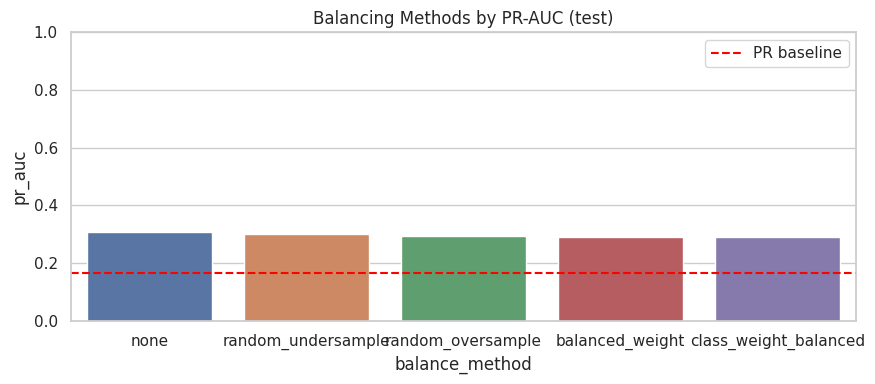

In [12]:
plt.figure()
plot_df = balancing_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='balance_method', y='pr_auc', hue='balance_method', dodge=False, legend=False)

pr_auc_baseline = float((pd.Series(y_test_local).map(label_to_int) == 1).mean())
plt.axhline(pr_auc_baseline, color='red', linestyle='--', linewidth=1.5, label='PR baseline')
plt.legend()

plt.title('Balancing Methods by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


`balanced_weight` in this notebook means class-balanced training via
`BCEWithLogitsLoss(pos_weight=...)` inside the PyTorch loop.

Compare it against `none` and sampling-based balancing methods using PR-AUC,
then validate with `F1-macro` and `balanced_accuracy`.


## 4) Feature selection comparison (fixed model)

Fixed model: `Adam` + architecture `(256, 256)`.
Compare `all features` vs `SelectKBest(mutual_info_classif)` on train split.


In [13]:
# Fit one preprocessor to estimate transformed feature count and set valid k values.
probe_prep = make_preprocessor()
X_train_probe = probe_prep.fit_transform(X_train_local, Y_train_local)
n_transformed_features = X_train_probe.shape[1]

candidate_k = [50, 100, 200, 300]
valid_k = [k for k in candidate_k if k < n_transformed_features]

feature_selection_configs = [('all_features', None)] + [(f'k_{k}', k) for k in valid_k]

feature_selection_rows = []
feature_selection_models = {}

for run_name, k in feature_selection_configs:
    row, fitted = evaluate_torch_mlp(
        run_name=run_name,
        hidden=(256, 256),
        optimizer_name='adam',
        lr=1e-3,
        class_balanced=True,
        k_select=k,
    )
    row['k_selected'] = n_transformed_features if k is None else int(k)
    feature_selection_rows.append(row)
    feature_selection_models[run_name] = fitted

feature_selection_df = pd.DataFrame(feature_selection_rows).sort_values('pr_auc', ascending=False).reset_index(drop=True)
feature_selection_df['rank_pr_auc'] = feature_selection_df['pr_auc'].rank(ascending=False, method='min').astype(int)

display(
    feature_selection_df[['run', 'k_selected', 'pr_auc', 'f1_macro', 'balanced_accuracy', 'rank_pr_auc']]
)


,run,k_selected,pr_auc,f1_macro,balanced_accuracy,rank_pr_auc
0,all_features,324,0.325683,0.519582,0.633007,1
1,k_300,300,0.299490,0.525076,0.632904,2
2,k_200,200,0.270827,0.485066,0.611708,3
3,k_100,100,0.253906,0.575677,0.635901,4
4,k_50,50,0.235277,0.519652,0.564819,5


**Decision — Features: `all_features`.**

`all_features` is selected because it is rank 1 on PR-AUC (`0.325683`). Feature pruning reduced PR-AUC in all tested `k` settings (`k_300=0.299490`, `k_200=0.270827`, `k_100=0.253906`, `k_50=0.235277`).

**Final configuration:** `optimizer=sgd_nesterov`, `architecture=narrow_128_64`, `balancing=none`, `features=all_features`.


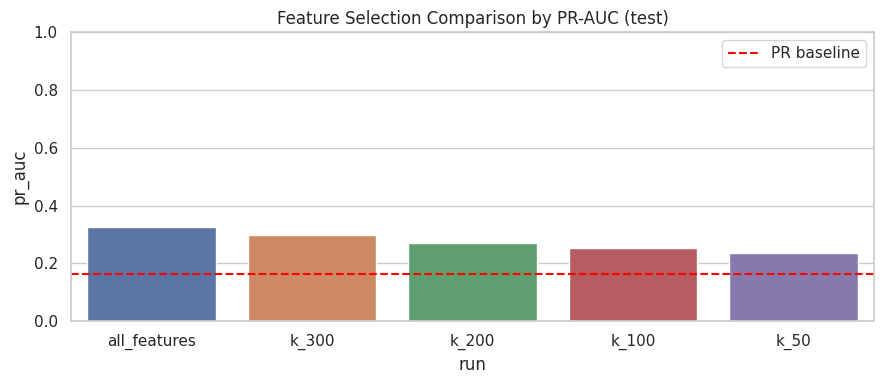

In [14]:
plt.figure()
plot_df = feature_selection_df.sort_values('pr_auc', ascending=False)
sns.barplot(data=plot_df, x='run', y='pr_auc', hue='run', dodge=False, legend=False)

pr_auc_baseline = float((pd.Series(y_test_local).map(label_to_int) == 1).mean())
plt.axhline(pr_auc_baseline, color='red', linestyle='--', linewidth=1.5, label='PR baseline')
plt.legend()

plt.title('Feature Selection Comparison by PR-AUC (test)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
